# Module 2 — Colorectal Cancer HIPEC Agents: Adverse Reactions

**Prerequisite:** Run `01_hipec_explore.ipynb` first to create the `oxaliplatin_analysis` and `mitomycin_analysis` tables.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

db_path = r"C:\Users\palla\OneDrive\Documents\Coding Projects\FDA_FAERS\database\faers.db"
conn = sqlite3.connect(db_path)

## Step 1: Top Reactions — Oxaliplatin

In [2]:
# Top adverse reactions for oxaliplatin (PS/SS reports only)
oxa_reactions = pd.read_sql_query("""
    SELECT r.pt AS reaction, COUNT(DISTINCT r.primaryid) AS reports
    FROM reac r
    JOIN (SELECT DISTINCT primaryid FROM oxaliplatin_analysis) o
        ON r.primaryid = o.primaryid
    GROUP BY r.pt
    ORDER BY reports DESC
    LIMIT 20
""", conn)

oxa_reactions

,reaction,reports
0,Off label use,771
1,Diarrhoea,619
2,Disease progression,603
3,Nausea,472
4,Neuropathy peripheral,415
5,Neutropenia,362
6,Vomiting,357
7,Drug ineffective,329
8,Thrombocytopenia,309
9,Myelosuppression,304


## Step 2: Top Reactions — Mitomycin C

In [3]:
# Top adverse reactions for mitomycin C (PS/SS reports only)
mmc_reactions = pd.read_sql_query("""
    SELECT r.pt AS reaction, COUNT(DISTINCT r.primaryid) AS reports
    FROM reac r
    JOIN (SELECT DISTINCT primaryid FROM mitomycin_analysis) m
        ON r.primaryid = m.primaryid
    GROUP BY r.pt
    ORDER BY reports DESC
    LIMIT 20
""", conn)

mmc_reactions

,reaction,reports
0,Drug ineffective,37
1,Disease progression,31
2,Off label use,20
3,Pancreatic carcinoma metastatic,12
4,Pulmonary veno-occlusive disease,11
5,Peritonitis,9
6,Neuropathy peripheral,9
7,Device related sepsis,9
8,Thrombotic microangiopathy,8
9,Acute kidney injury,8


## Step 3: Side-by-Side Comparison

Comparing the top reaction profiles of both drugs highlights where their toxicity
profiles overlap and where they diverge. Oxaliplatin is well known for peripheral
neuropathy; mitomycin C for pulmonary toxicity and hemolytic uremic syndrome.

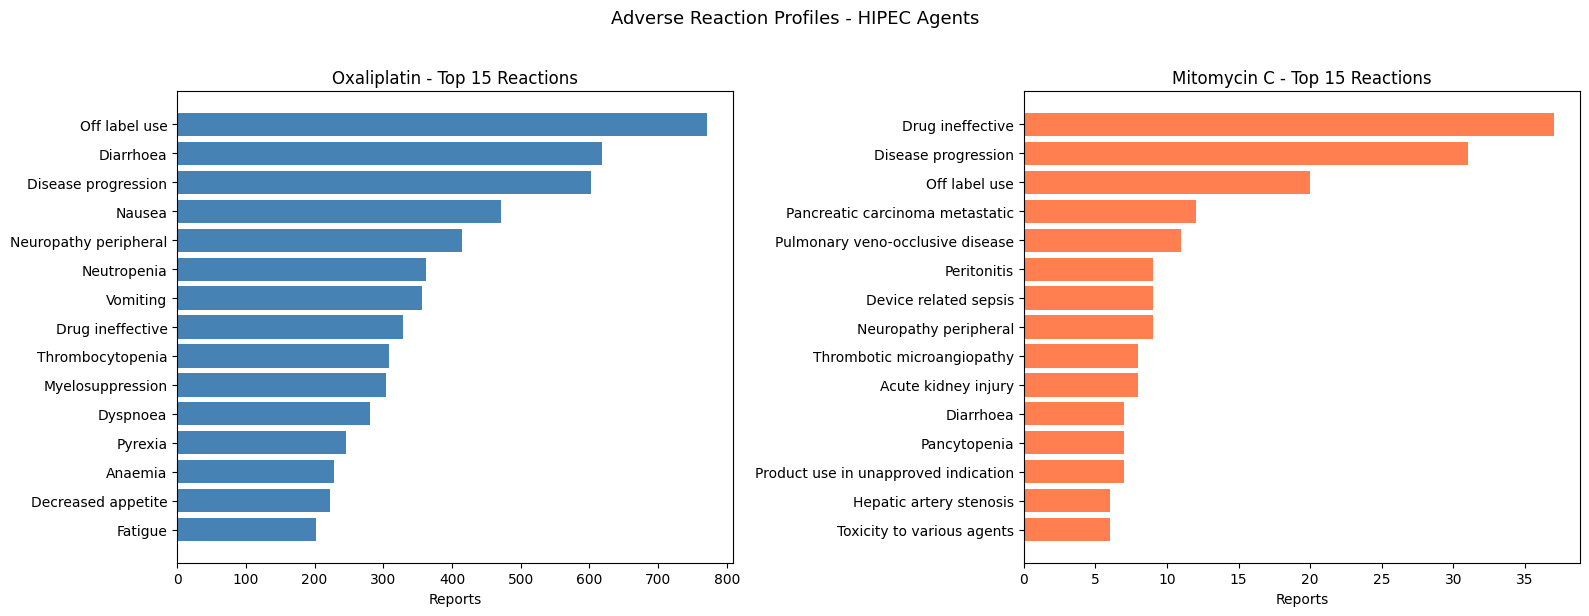

In [4]:
# Side-by-side bar chart comparing top 15 reactions for each drug
oxa_top = oxa_reactions.head(15).sort_values('reports')
mmc_top = mmc_reactions.head(15).sort_values('reports')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.barh(oxa_top['reaction'], oxa_top['reports'], color='steelblue')
ax1.set_title('Oxaliplatin - Top 15 Reactions')
ax1.set_xlabel('Reports')

ax2.barh(mmc_top['reaction'], mmc_top['reports'], color='coral')
ax2.set_title('Mitomycin C - Top 15 Reactions')
ax2.set_xlabel('Reports')

plt.suptitle('Adverse Reaction Profiles - HIPEC Agents', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()